# Comparação dos Resultados dos Modelos

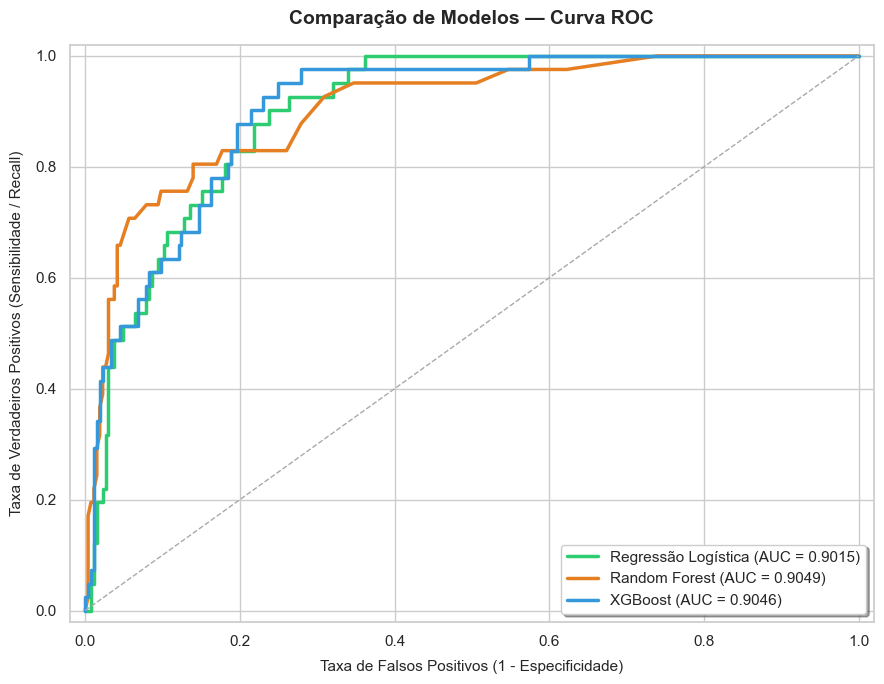


                 DESEMPENHO: REGRESSÃO LOGÍSTICA)                
                 precision    recall  f1-score   support

Qualidade Comum       0.98      0.74      0.84       265
 Alta Qualidade       0.35      0.90      0.50        41

       accuracy                           0.76       306
      macro avg       0.66      0.82      0.67       306
   weighted avg       0.90      0.76      0.80       306


                    DESEMPENHO: RANDOM FOREST                    
                 precision    recall  f1-score   support

Qualidade Comum       0.95      0.94      0.95       265
 Alta Qualidade       0.66      0.71      0.68        41

       accuracy                           0.91       306
      macro avg       0.81      0.83      0.82       306
   weighted avg       0.91      0.91      0.91       306


                       DESEMPENHO: XGBOOST                       
                 precision    recall  f1-score   support

Qualidade Comum       0.94      0.88      0.91     

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# ==============================================================================
# 1. CARREGAMENTO DOS DADOS DOS NOTEBOOKS ANTERIORES
# ==============================================================================

# Lendo os dados salvos pelos outros notebooks
lr_dados = pd.read_csv('../data/resultados_logistica.csv')
rf_dados = pd.read_csv('../data/resultados_random_forest.csv')
xgb_dados = pd.read_csv('../data/resultados_xgboost.csv')

# Mapeando para as variáveis do código de comparação
y_test = lr_dados['y_real']
y_prob_ot = lr_dados['y_prob_lr']
y_pred_thresh = lr_dados['y_pred_lr']

y_scores_original = rf_dados['y_prob_rf']
y_pred_definitivo = rf_dados['y_pred_rf']

y_prob_xgb_final = xgb_dados['y_prob_xgb']
y_pred_xgb_final = xgb_dados['y_pred_xgb']


# ==============================================================================
# 2. GRÁFICO COMPARATIVO DA CURVA ROC
# ==============================================================================
plt.figure(figsize=(9, 7))
sns.set_theme(style="whitegrid")

# --- Curva ROC: Regressão Logística ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_ot)
auc_lr = roc_auc_score(y_test, y_prob_ot)
plt.plot(fpr_lr, tpr_lr, color='#2ecc71', lw=2.5, label=f'Regressão Logística (AUC = {auc_lr:.4f})')

# --- Curva ROC: Random Forest ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_scores_original)
auc_rf = roc_auc_score(y_test, y_scores_original)
plt.plot(fpr_rf, tpr_rf, color='#e67e22', lw=2.5, label=f'Random Forest (AUC = {auc_rf:.4f})')

# --- Curva ROC: XGBoost ---
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb_final)
auc_xgb = roc_auc_score(y_test, y_prob_xgb_final)
plt.plot(fpr_xgb, tpr_xgb, color='#3498db', lw=2.5, label=f'XGBoost (AUC = {auc_xgb:.4f})')

# Linha de referência diagonal (classificador aleatório)
plt.plot([0, 1], [0, 1], color='darkgray', linestyle='--', lw=1)

# Customização estética do gráfico
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=11, labelpad=8)
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade / Recall)', fontsize=11, labelpad=8)
plt.title('Comparação de Modelos — Curva ROC', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.tight_layout()
plt.show()


# ==============================================================================
# 3. RELATÓRIOS DE CLASSIFICAÇÃO (MÉTRICAS DETALHADAS)
# ==============================================================================
largura_bloco = 65

print("\n" + "=" * largura_bloco)
print("DESEMPENHO: REGRESSÃO LOGÍSTICA)".center(largura_bloco))
print("=" * largura_bloco)
print(classification_report(y_test, y_pred_thresh, target_names=['Qualidade Comum', 'Alta Qualidade']))

print("\n" + "=" * largura_bloco)
print("DESEMPENHO: RANDOM FOREST".center(largura_bloco))
print("=" * largura_bloco)
print(classification_report(y_test, y_pred_definitivo, target_names=['Qualidade Comum', 'Alta Qualidade']))

print("\n" + "=" * largura_bloco)
print("DESEMPENHO: XGBOOST".center(largura_bloco))
print("=" * largura_bloco)
print(classification_report(y_test, y_pred_xgb_final, target_names=['Qualidade Comum', 'Alta Qualidade']))
print("=" * largura_bloco)

FileNotFoundError: [Errno 2] No such file or directory: '../results/comparacao_modelos_painel.png'

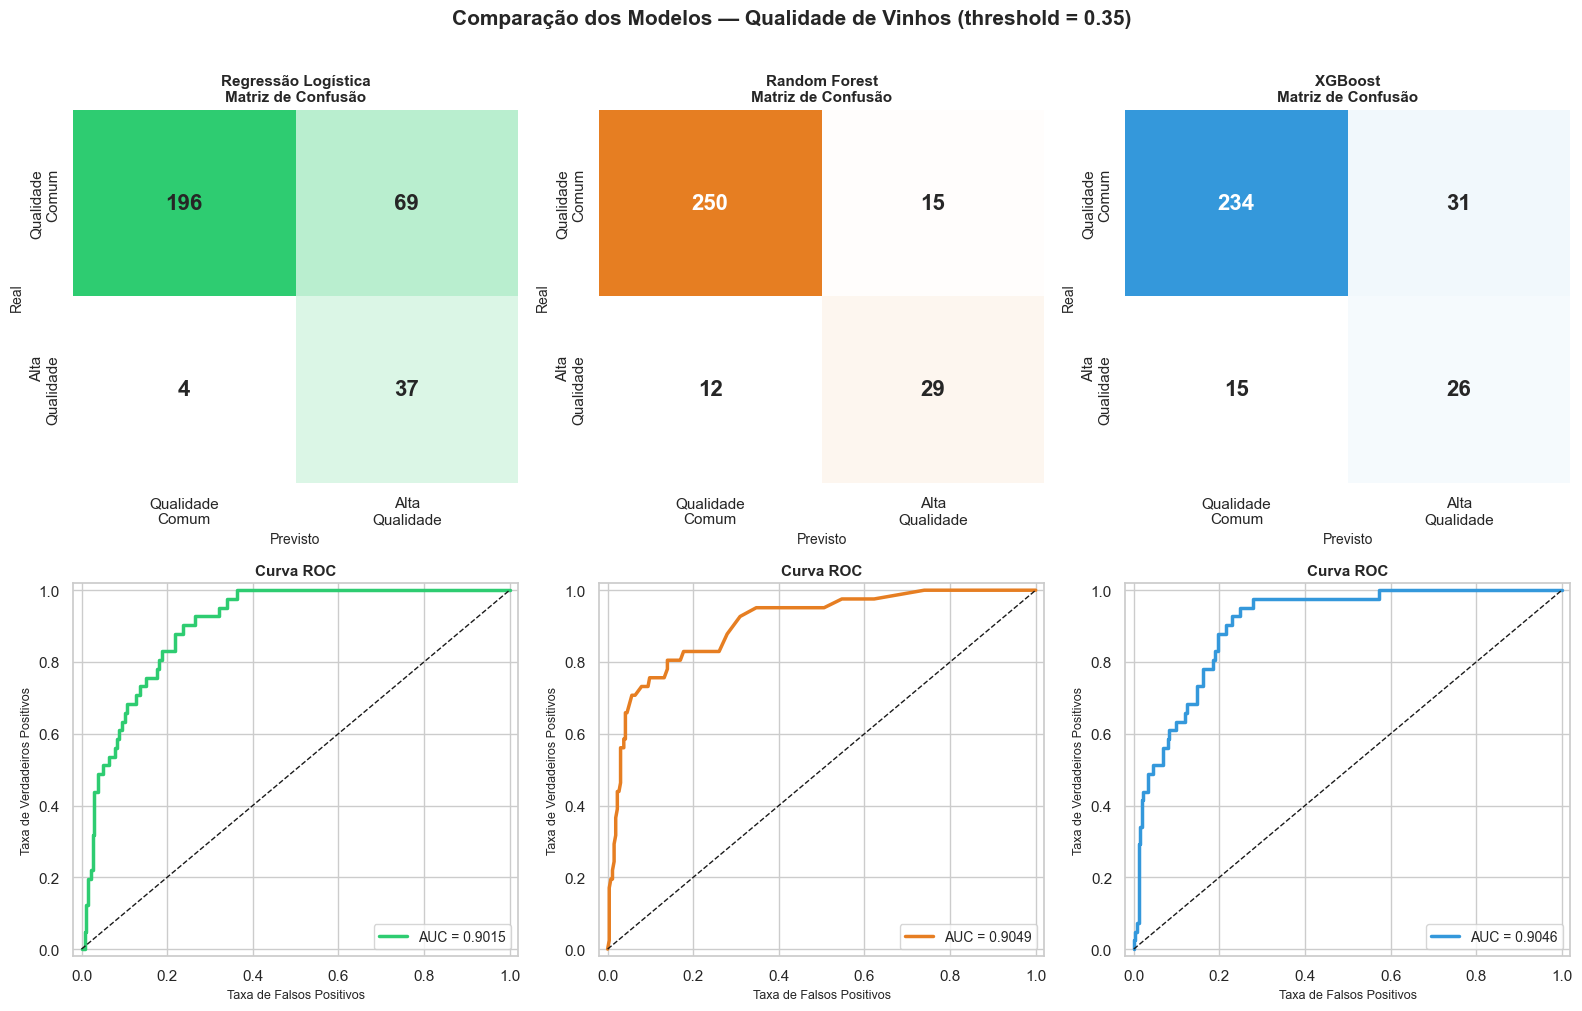

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# Paleta personalizada por modelo
cmaps = {
    "Regressão Logística": mcolors.LinearSegmentedColormap.from_list("", ["white", "#2ecc71"]),
    "Random Forest":       mcolors.LinearSegmentedColormap.from_list("", ["white", "#e67e22"]),
    "XGBoost":             mcolors.LinearSegmentedColormap.from_list("", ["white", "#3498db"]),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Comparação dos Modelos — Qualidade de Vinhos (threshold = 0.35)",
             fontsize=15, fontweight="bold", y=1.01)

for col, m in enumerate(modelos):

    # --- Matriz de Confusão ---
    ax_cm = axes[0, col]
    cm = confusion_matrix(y_test, m["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmaps[m["nome"]], ax=ax_cm,
                linewidths=0, cbar=False,
                annot_kws={"size": 16, "weight": "bold"},
                xticklabels=["Qualidade\nComum", "Alta\nQualidade"],
                yticklabels=["Qualidade\nComum", "Alta\nQualidade"])
    ax_cm.set_title(f"{m['nome']}\nMatriz de Confusão", fontsize=11, fontweight="bold")
    ax_cm.set_xlabel("Previsto", fontsize=10)
    ax_cm.set_ylabel("Real", fontsize=10)

    # --- Curva ROC ---
    ax_roc = axes[1, col]
    fpr, tpr, _ = roc_curve(y_test, m["y_prob"])
    auc = roc_auc_score(y_test, m["y_prob"])
    ax_roc.plot(fpr, tpr, color=m["cor"], lw=2.5, label=f"AUC = {auc:.4f}")
    ax_roc.plot([0, 1], [0, 1], "k--", lw=1)
    ax_roc.set_xlim([-0.02, 1.02]); ax_roc.set_ylim([-0.02, 1.02])
    ax_roc.set_title("Curva ROC", fontsize=11, fontweight="bold")
    ax_roc.set_xlabel("Taxa de Falsos Positivos", fontsize=9)
    ax_roc.set_ylabel("Taxa de Verdadeiros Positivos", fontsize=9)
    ax_roc.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig('../results/comparacao_modelos_painel.png', dpi=150, bbox_inches='tight')
plt.show()